In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm

In [2]:
path_model = '/media/drdarby/Elements/data/Thesis/LLC4320/Case_Studies/LLC4320/'
case_study_from= ['filament/','summer_eddy/']

In [3]:
output_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/case_studies/' #eddy, fil

In [4]:
case_study_to = ['fil/','eddy/']

In [5]:
variables = ['Theta','Salt','U','V','W']

In [6]:
theta_files, theta_filepath = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[0],file_end='nc')


In [9]:
salt_files, salt_filepath = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[1],file_end='nc')


In [40]:
u_files, u_filepath = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[2],file_end='nc')


In [41]:
v_files, v_filepath = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[3],file_end='nc')


In [12]:
w_files, w_filepath = tools.get_data_paths_from_binary(output_path+case_study_to[0],variables[4],file_end='nc')


In [11]:
grid_files, grid_filepath = tools.get_data_paths_from_binary(path_model+case_study_from[0],'grid',delim='_',file_end='84')


In [3]:
depth = np.fromfile(grid_filepath[1],'>f4')
#file = np.reshape(file, shape)

NameError: name 'grid_filepath' is not defined

In [ ]:
depth

In [8]:
Theta = xr.open_mfdataset(theta_filepath)

In [13]:
W = xr.open_mfdataset(w_filepath)

In [23]:
# Theta['k'] = depth
# Theta = Theta.rename({'k':'depths'})
W['k'] = depth
W = W.rename({'k':'depths'})

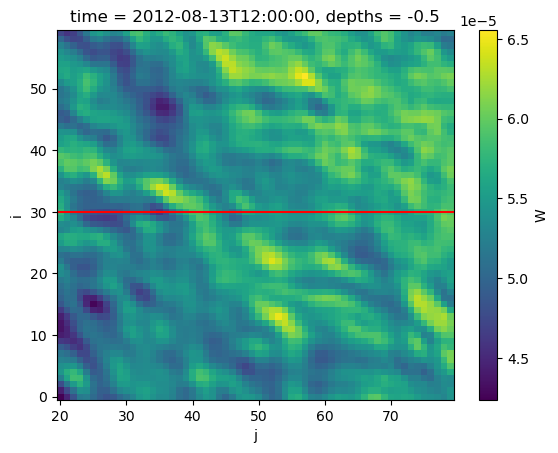

In [24]:
W['W'].isel(time=300,depths=0,j=slice(20,80),i=slice(0,60) ).plot()
plt.plot(W.j,[30]*len(W.j),'r')

In [27]:
W_filt = tools.filt(W['W'])
W_filt = tools.filt(W_filt,T=15)

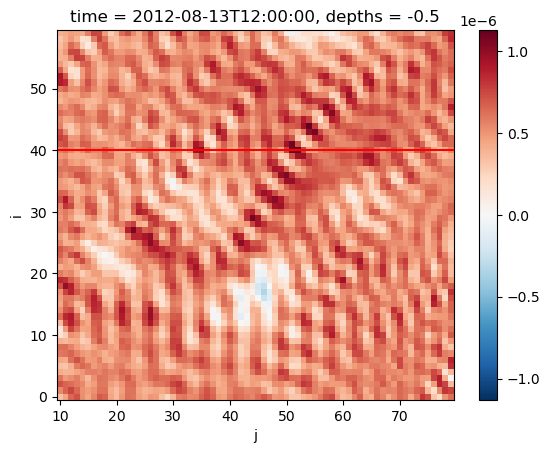

In [43]:
W_filt.isel(time=300,depths=0,j=slice(10,80),i=slice(0,60) ).plot()
plt.plot(W.j,[40]*len(W.j),'r')

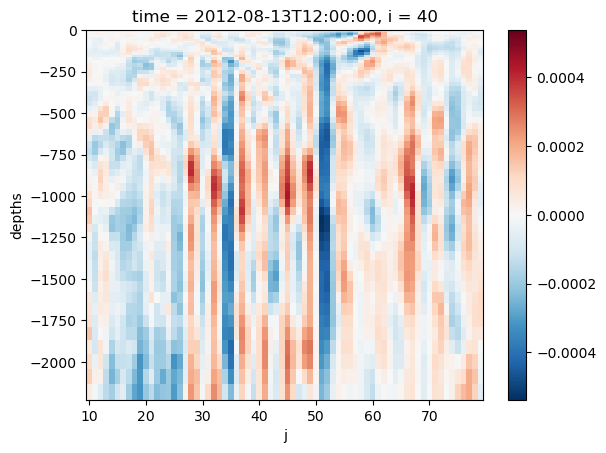

In [49]:



W_filt.isel(time=300,i=40 ,j=slice(10,80),depths=slice(0,70)).plot()


In [13]:
Theta['k'] = depth
Theta = Theta.rename({'k':'depths'})

NameError: name 'grid' is not defined

In [15]:
Theta

<xarray.Dataset>
Dimensions:  (time: 721, depths: 84, i: 173, j: 163)
Coordinates:
  * time     (time) datetime64[ns] 2012-08-01 2012-08-01T01:00:00 ... 2012-08-31
  * depths   (depths) >f4 -0.5 -1.57 -2.79 ... -4.019e+03 -4.266e+03 -4.535e+03
  * i        (i) int64 0 1 2 3 4 5 6 7 8 ... 164 165 166 167 168 169 170 171 172
  * j        (j) int64 0 1 2 3 4 5 6 7 8 ... 154 155 156 157 158 159 160 161 162
Data variables:
    Theta    (time, depths, i, j) float32 dask.array<chunksize=(1, 84, 173, 163), meta=np.ndarray>

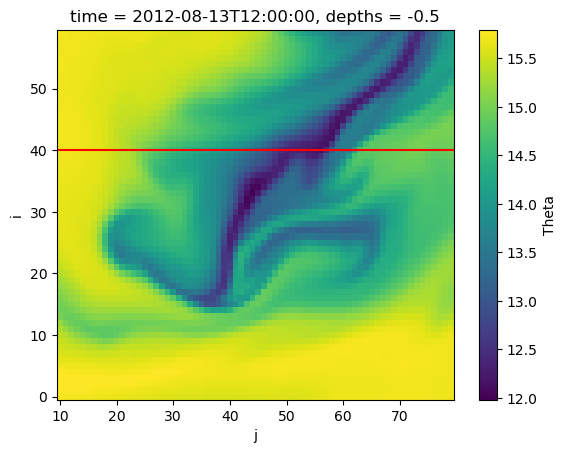

In [14]:
Theta['Theta'].isel(time=300,depths=0,j=slice(10,80),i=slice(0,60) ).plot()
#plt.plot(Theta.j,[40]*len(Theta.j),'r')

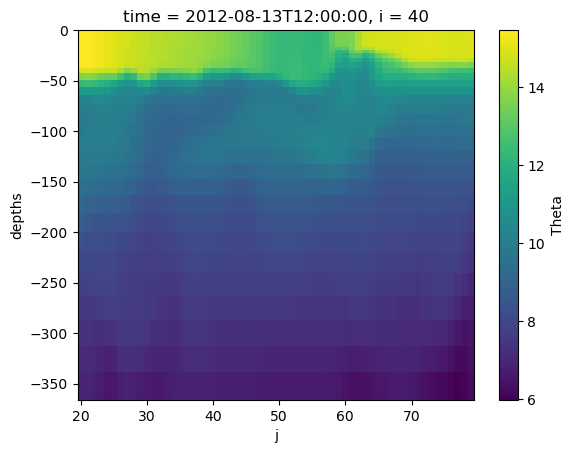

In [46]:
Theta['Theta'].isel(time=300+24,i=40 ,j=slice(20,80),depths=slice(0,35)).plot()


### 